In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input


Matplotlib is building the font cache; this may take a moment.


In [2]:

df = pd.read_csv("HousingData.csv")

df = df.fillna(df.mean())

x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

scaler_x = StandardScaler()
scaler_y = StandardScaler()

x = scaler_x.fit_transform(x)
y = scaler_y.fit_transform(y.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)



In [3]:
model = Sequential([
    Input(shape=(13,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

In [4]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.8524 - mae: 0.6485 - val_loss: 0.5054 - val_mae: 0.4781
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5242 - mae: 0.4894 - val_loss: 0.3804 - val_mae: 0.3957
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3866 - mae: 0.4112 - val_loss: 0.2934 - val_mae: 0.3467
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2882 - mae: 0.3587 - val_loss: 0.2598 - val_mae: 0.3466
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2435 - mae: 0.3264 - val_loss: 0.2556 - val_mae: 0.3444
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2108 - mae: 0.3066 - val_loss: 0.2282 - val_mae: 0.3213
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1951 - mae: 0.2953 - val_loss: 0.2269 - val_mae: 0.3144
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1797 - mae: 0.2774 - val_loss: 0.2204 - val_mae: 0.3066
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.169

In [5]:
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1657 - mae: 0.2470
Test Loss: 0.16572900116443634
Test MAE: 0.24697817862033844


In [6]:
predictions = model.predict(X_test)
predictions = scaler_y.inverse_transform(predictions)
y_test = scaler_y.inverse_transform(y_test)

for i in range(5):
    print("Predicted:", round(predictions[i][0], 2), "Actual:", round(y_test[i][0], 2))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted: 28.08 Actual: 23.6
Predicted: 37.44 Actual: 32.4
Predicted: 15.59 Actual: 13.6
Predicted: 21.92 Actual: 22.8
Predicted: 15.26 Actual: 16.1


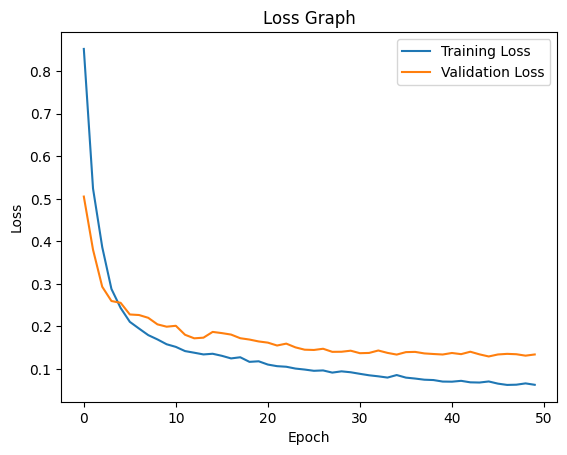

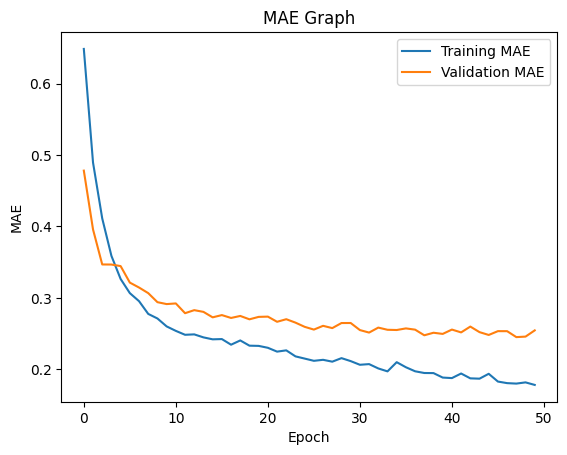

In [7]:

import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('MAE Graph')
plt.legend()
plt.show()